# Stage 00b — Descriptions CSV + Figure Cropping & Label Matching

**What this notebook does:**

1. Exports all *Brief Description of the Drawings* texts from the PatSeer Excel
   into a single `data/descriptions.csv`.

2. Detects and crops every sub-figure on each drawing sheet using
   **DocLayout-YOLO** (document layout detector) + **EasyOCR** (label reader) —
   free, local, GPU-accelerated.

The matching logic:
1. DocLayout-YOLO detects `figure` and `figure_caption` regions on each sheet
2. For each figure box, EasyOCR tries to read the label via a cascade of passes:
   top-left corner → top-right corner → below strip (350 px) → side margins
3. Each crop is saved as `_F<label>.png` (matched) or `_Fu.png` (needs review)
4. FAT files are always copied whole as `_Fu`

**Output naming:**

| Label source | Output filename | Meaning |
|---|---|---|
| OCR label match | `US…_F1A.png` | matched to FIG. 1A |
| Unmatched / FAT / error | `US…_Fu.png` | needs review |

Output is written to `matched/<patent_id>/` — raw files are never modified.

**Where it fits in the pipeline:**
```
00a  (PatSeer download)
 ↓
00b  ←  YOU ARE HERE  (descriptions CSV + DocLayout-YOLO → _F / _Fu labels)
 ↓
01   (human review for _Fu files)
 ↓
02   (pad + resize to 518×518)
```

---

| Cell | What it does |
|------|------|
| 1 | CUDA check |
| 2 | Load config + Excel, save descriptions.csv |
| 3 | Build DocLayout-YOLO + EasyOCR engine (once per session) |
| 4 | Run pipeline over all patents (respects `scan_limit` from config) |
| 5 | Save review CSV + show flagged crops |

In [1]:
import torch
print("Is CUDA active inside Jupyter?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Connected GPU Model:", torch.cuda.get_device_name(0))

Is CUDA active inside Jupyter?: True
Connected GPU Model: NVIDIA GeForce RTX 2080 Ti


In [2]:
import sys
import os
import pandas as pd
from pathlib import Path

notebook_dir = Path(os.getcwd())
project_root = notebook_dir.parent
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from config_loader import load_config
from extractor import load_patseer_excel, save_descriptions_csv
import doclayout_matcher as dm

cfg = load_config()

print("Config loaded. Key paths:")
print("  raw_images :", cfg["paths"]["raw_images"])
print("  matched    :", cfg["paths"]["matched"])
print("  data       :", cfg["paths"]["data"])

Config loaded. Key paths:
  raw_images : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/raw
  matched    : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/matched
  data       : /mnt/storage_11tb/Drive_files_to_syncronize/3 - Images DataSets & Labelling Outputs/1639_DS/data


In [3]:
excel_path = Path(cfg["paths"]["patseer_excel"])
print(f"Reading PatSeer data from: {excel_path.name}...")
patseer_index = load_patseer_excel(excel_path)

desc_csv_path = Path(cfg["paths"]["data"]) / "descriptions.csv"
save_descriptions_csv(patseer_index, desc_csv_path)

df = pd.read_csv(desc_csv_path)
print(f"descriptions.csv saved — {len(df)} records.")

Reading PatSeer data from: 1639__dataset_08_06_26.xlsx...


/home/vasco/anaconda3/envs/doclayout_yolo2/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


PatSeer Excel: 1639__dataset_08_06_26.xlsx  (1639 rows, 102 columns)
Columns:
  [  0] 'Record Number'
  [  1] 'Title'
  [  2] 'Abstract'
  [  3] 'Description of Drawings'
  [  4] 'CPC'
  [  5] 'PDF Link'
  [  6] 'Record Type'
  [  7] 'Publication/Issue Date'
  [  8] 'Filing/Application Date'
  [  9] 'Estimated Expiry Date'
  [ 10] 'EFAM Earliest Priority Date'
  [ 11] 'EFAM Earliest Publication Date'
  [ 12] 'Priority Details'
  [ 13] 'Priority Dates (All)'
  [ 14] 'Application No.'
  [ 15] 'Priority Country Code'
  [ 16] 'Priority Year'
  [ 17] 'Register Legal Status'
  [ 18] 'Register Legal Status Date'
  [ 19] 'Summary of Invention'
  [ 20] 'Designated States'
  [ 21] 'Active in Designated States'
  [ 22] 'Field of search'
  [ 23] 'Industry'
  [ 24] 'Tech Domain'
  [ 25] 'Tech Sub Domain'
  [ 26] 'Description'
  [ 27] 'Claims'
  [ 28] 'Number Of Claims'
  [ 29] 'No. of Independent Claims'
  [ 30] 'Independent Claims'
  [ 31] 'First Claim'
  [ 32] 'Advantages of Invention'
  [ 33] 'N

In [4]:
# ── Cell 2b — Batch selector ──────────────────────────────────────────────────
# Split the 1639 patents into batches of ≥200, grouped by Applicant.
# Set BATCH_INDEX to run one batch at a time (0, 1, 2, ...).
# Set BATCH_INDEX = None to run all patents (original behaviour).

BATCH_SIZE  = 200
BATCH_INDEX = 0      # ← change this to run different batches

def make_batches(dataframe, batch_size: int) -> list:
    """
    Group patents by 'Applicant' column (or 'Assignee' / 'assignee' — tries all three),
    then pack groups into batches of at least `batch_size` rows each.
    Returns a list of DataFrames, one per batch.
    """
    import pandas as pd

    # Detect the applicant column — try common PatSeer column names
    applicant_col = next(
        (c for c in ("Applicant", "Assignee", "assignee", "applicant")
         if c in dataframe.columns),
        None,
    )

    if applicant_col is None:
        print("⚠  No Applicant/Assignee column found — batching by row order only.")
        # Fallback: equal-size sequential chunks
        chunks = [dataframe.iloc[i:i+batch_size] for i in range(0, len(dataframe), batch_size)]
        return chunks

    # Group by applicant, sort groups largest-first so we fill batches efficiently
    groups = [grp for _, grp in dataframe.groupby(applicant_col, sort=False)]
    groups.sort(key=len, reverse=True)

    batches, current, current_size = [], [], 0
    for grp in groups:
        current.append(grp)
        current_size += len(grp)
        if current_size >= batch_size:
            batches.append(pd.concat(current).reset_index(drop=True))
            current, current_size = [], 0
    if current:
        # Merge last undersized group into the previous batch (keeps ≥200 constraint)
        if batches:
            batches[-1] = pd.concat([batches[-1], pd.concat(current)]).reset_index(drop=True)
        else:
            batches.append(pd.concat(current).reset_index(drop=True))

    return batches


all_batches = make_batches(df, BATCH_SIZE)
print(f"Total patents   : {len(df)}")
print(f"Batches created : {len(all_batches)}")
for i, b in enumerate(all_batches):
    print(f"  Batch {i}: {len(b)} patents")

if BATCH_INDEX is None:
    run_df = df
    print(f"\nRunning ALL {len(run_df)} patents.")
else:
    if BATCH_INDEX >= len(all_batches):
        raise ValueError(f"BATCH_INDEX {BATCH_INDEX} out of range — only {len(all_batches)} batches exist.")
    run_df = all_batches[BATCH_INDEX]
    print(f"\nRunning Batch {BATCH_INDEX}: {len(run_df)} patents.")


⚠  No Applicant/Assignee column found — batching by row order only.
Total patents   : 1639
Batches created : 9
  Batch 0: 200 patents
  Batch 1: 200 patents
  Batch 2: 200 patents
  Batch 3: 200 patents
  Batch 4: 200 patents
  Batch 5: 200 patents
  Batch 6: 200 patents
  Batch 7: 200 patents
  Batch 8: 39 patents

Running Batch 0: 200 patents.


In [5]:
# Build DocLayout-YOLO + EasyOCR engine — load once, reuse for all patents.
# First run downloads EasyOCR models (~100 MB). Subsequent runs are instant.
# Qwen2.5-VL fallback is loaded lazily on first OCR miss (no upfront VRAM cost).
engine = dm.build_engine()
model, reader, device = engine[0], engine[1], engine[2]
print("Engine ready on:", device)
print("YOLO classes   :", model.names)

Engine ready on: cuda:0
YOLO classes   : {0: 'title', 1: 'plain text', 2: 'abandon', 3: 'figure', 4: 'figure_caption', 5: 'table', 6: 'table_caption', 7: 'table_footnote', 8: 'isolate_formula', 9: 'formula_caption'}


In [6]:
import re, time, shutil

raw_dir     = Path(cfg["paths"]["raw_images"])
matched_dir = Path(cfg["paths"]["matched"])
matched_dir.mkdir(parents=True, exist_ok=True)

scan_limit = cfg["extractor"].get("scan_limit", None)
# run_df is now set by Cell 2b batch selector.
# scan_limit still applies as a secondary cap if set in config.
if scan_limit:
    run_df = run_df.head(scan_limit)
print(f"Running on {len(run_df)} patents (scan_limit={scan_limit})...")
print(f"Running on {len(run_df)} patents  (scan_limit={scan_limit})...")

# Normalise a patent ID to its bare alphanumeric core for folder matching.
# Strips PatSeer numeric download suffix (_85775850), then PAFP/PAF, then kind codes.
_CLEAN_RE   = re.compile(r"[^A-Za-z0-9]")
_NUM_SUFFIX = re.compile(r"_\d+$")          # e.g. US11787551B1_85775850 → US11787551B1
_DL_SUFFIX  = re.compile(r"PAFP$|PAF$", re.IGNORECASE)
_KIND_CODES = ["A1","A2","A3","B1","B2","C1","U1"]

def _core(pid: str) -> str:
    p = _NUM_SUFFIX.sub("", pid)            # strip _12345678 before cleaning
    c = _CLEAN_RE.sub("", p).upper()
    c = _DL_SUFFIX.sub("", c)
    for sfx in _KIND_CODES:
        if c.endswith(sfx):
            return c[:-len(sfx)]
    return c

folder_map = {_core(p.name): p for p in raw_dir.iterdir() if p.is_dir()}

# Drawing sheet filename patterns found across the full dataset:
#   US20220267016A1_D00001.png   USNPAFP_imgN.png   WON_fig_N.png
#   pat1.png   1.png   FT_1.png   imgfN.png   imgafN.png   HDA1.png
# Rule: any PNG that looks like it carries a drawing sheet index number,
# excluding manifest/metadata files.
_NON_SHEET = re.compile(
    r"manifest|thumbnail|cover|abstract|front.?page",
    re.IGNORECASE,
)
_SHEET_RE = re.compile(
    r"""
    (?:
        _[Dd]\d{3,}          |   # _D00001  (USPTO bulk format)
        PAFP_img\d           |   # US...PAFP_img1
        PAF_img\d            |   # WO...PAF_img1
        _img[af]?\d          |   # _img1  _imgf1  _imgaf1
        fig_\d               |   # fig_01
        record__fig_\d       |   # record__fig_01
        ^img[af]?\d          |   # imgf0001  imgaf001 (starts with img)
        ^pat\d               |   # pat1.png
        ^FT_\d               |   # FT_1.png
        ^HDA\d               |   # HDA1.png
        ^\d+\.               |   # 1.png  2.png
        ^srep\d              |   # srep1.png
        sN_img\d                 # SDN...SN_img1
    )
    """,
    re.VERBOSE | re.IGNORECASE,
)

def is_sheet(f: "Path") -> bool:
    if f.suffix.lower() != ".png":
        return False
    if _NON_SHEET.search(f.name):
        return False
    return bool(_SHEET_RE.search(f.name))

rows = []
t0 = time.time()

for _, row in run_df.iterrows():
    excel_id = str(row.get("patent_id", "")).strip()
    if not excel_id:
        continue

    folder = folder_map.get(_core(excel_id))
    if folder is None:
        print(f"  ⚠  No raw folder for {excel_id} — skipping")
        continue

    out_dir = matched_dir / folder.name
    out_dir.mkdir(parents=True, exist_ok=True)

    files     = sorted(folder.iterdir())
    img_files = [f for f in files if is_sheet(f)]
    fat_files = [f for f in files if re.search(r"_FAT\d", f.name)]

    for f in fat_files:
        out_path = out_dir / f"{f.stem}_Fu.png"
        shutil.copy2(f, out_path)
        rows.append({"patent_id": excel_id, "original": f.name, "output": out_path.name,
                     "label": None, "method": "fat_copy", "needs_review": True})

    for img_path in img_files:
        try:
            res = dm.process_image(engine, img_path, out_dir)
            for c in res["crops"]:
                rows.append({"patent_id": excel_id, "original": c["original"],
                             "output": c["output"], "label": c["label"],
                             "method": c["method"], "needs_review": c["needs_review"]})
        except Exception as e:
            print(f"    ❌ {img_path.name}: {e}")

    labelled = sum(1 for r in rows if r["patent_id"] == excel_id and not r["needs_review"])
    total    = sum(1 for r in rows if r["patent_id"] == excel_id)
    print(f"  ✓ {excel_id}  sheets={len(img_files)}  crops={total}  labelled={labelled}")

elapsed = time.time() - t0
results_df = pd.DataFrame(rows)

crops_csv = Path(cfg["paths"]["data"]) / "crops_mapping.csv"
results_df.to_csv(crops_csv, index=False)

print(f"\nDone in {elapsed:.0f}s  ({elapsed/max(1,len(run_df)):.1f}s/patent)")
print(f"Total crops : {len(results_df)}")
if not results_df.empty:
    labelled_n = (results_df["needs_review"] == False).sum()
    print(f"Auto-labelled: {labelled_n}/{len(results_df)} = {100*labelled_n/len(results_df):.0f}%")
    print(results_df.groupby("method")["output"].count())

Running on 1 patents (scan_limit=1)...
Running on 1 patents  (scan_limit=1)...
Loading local GPU Vision Model (4-bit): Qwen/Qwen2.5-VL-7B-Instruct...
Using model cache repository path: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Patent-Labelling-Tools/models/Qwen


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

VLM Engine loaded successfully on GPU within memory limits.
  ✓ US2022267016A1  sheets=11  crops=14  labelled=8

Done in 67s  (66.6s/patent)
Total crops : 14
Auto-labelled: 8/14 = 57%
method
doclayout_easyocr    14
Name: output, dtype: int64


In [7]:
if results_df.empty or "needs_review" not in results_df.columns:
    print("No crops produced — nothing to review.")
else:
    flagged_df = results_df[results_df["needs_review"] == True]
    review_csv = Path(cfg["paths"]["data"]) / "needs_human_review.csv"
    flagged_df.to_csv(review_csv, index=False)
    print(f"Saved {len(flagged_df)} flagged crops → {review_csv.name}")
    print(f"(Pass these to Step 01 — human review notebook)")
    if not flagged_df.empty:
        display(flagged_df[["patent_id","original","output","label","method"]].head(20))

Saved 6 flagged crops → needs_human_review.csv
(Pass these to Step 01 — human review notebook)


,patent_id,original,output,label,method
0,US2022267016A1,US2022267016A1_US20220267016A1_D00000.png,US2022267016A1_US20220267016A1_D00000_crop_0_F...,None,doclayout_easyocr
1,US2022267016A1,US2022267016A1_US20220267016A1_D00001.png,US2022267016A1_US20220267016A1_D00001_crop_0_F...,None,doclayout_easyocr
2,US2022267016A1,US2022267016A1_US20220267016A1_D00001.png,US2022267016A1_US20220267016A1_D00001_crop_1_F...,None,doclayout_easyocr
4,US2022267016A1,US2022267016A1_US20220267016A1_D00003.png,US2022267016A1_US20220267016A1_D00003_crop_0_F...,None,doclayout_easyocr
6,US2022267016A1,US2022267016A1_US20220267016A1_D00004.png,US2022267016A1_US20220267016A1_D00004_crop_1_F...,None,doclayout_easyocr
7,US2022267016A1,US2022267016A1_US20220267016A1_D00004.png,US2022267016A1_US20220267016A1_D00004_crop_2_F...,None,doclayout_easyocr


---
## Evaluation — inspect results inline

**Cell 6** — Summary stats (counts, labelling rate, method breakdown per patent)  
**Cell 7** — Visual grid: all crops for every patent, annotated with label + method  
**Cell 8** — Flagged-only reviewer: show just the `_Fu` crops that need human attention

In [8]:
# ── Cell 6 — Summary stats ────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path

crops_csv = Path(cfg["paths"]["data"]) / "crops_mapping.csv"
results_df = pd.read_csv(crops_csv)

if results_df.empty:
    print("crops_mapping.csv is empty — run the pipeline first (Cell 4).")
else:
    total      = len(results_df)
    labelled_n = (results_df["needs_review"] == False).sum()
    flagged_n  = (results_df["needs_review"] == True).sum()

    print(f"{'Total crops':<25} {total}")
    print(f"{'Auto-labelled (_F)':<25} {labelled_n}  ({100*labelled_n/total:.0f}%)")
    print(f"{'Needs review (_Fu)':<25} {flagged_n}  ({100*flagged_n/total:.0f}%)")
    print()

    # Per-patent breakdown
    per_patent = (
        results_df
        .groupby("patent_id")
        .agg(
            sheets   = ("original", "nunique"),
            crops    = ("output", "count"),
            labelled = ("needs_review", lambda x: (x == False).sum()),
            flagged  = ("needs_review", lambda x: (x == True).sum()),
        )
        .assign(pct=lambda d: (d["labelled"] / d["crops"] * 100).round(0).astype(int))
        .rename(columns={"pct": "labelled_%"})
        .sort_values("labelled_%")
    )
    display(per_patent)

    print()
    print("Method breakdown:")
    display(results_df.groupby("method")["output"].count().rename("crops").to_frame())

Total crops               14
Auto-labelled (_F)        8  (57%)
Needs review (_Fu)        6  (43%)



,sheets,crops,labelled,flagged,labelled_%
patent_id,,,,,
US2022267016A1,11,14,8,6,57



Method breakdown:


,crops
method,
doclayout_easyocr,14


In [9]:
# ── Cell 7 — Interactive crop + description viewer (← → buttons) ─────────────
import re, textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, clear_output

matched_dir = Path(cfg["paths"]["matched"])
crops_df    = pd.read_csv(Path(cfg["paths"]["data"]) / "crops_mapping.csv")
desc_df     = pd.read_csv(Path(cfg["paths"]["data"]) / "descriptions.csv")
desc_lookup = desc_df.set_index("patent_id")["description_of_drawings"].to_dict()

_FIG_RE = re.compile(
    r"FIG\.?\s*(\d+\s*[A-Za-z]?)\s+(?:and\s+FIG\.?\s*\d+\s*[A-Za-z]?\s+)?(?:is|are|show|illustrate|depict)\b",
    re.IGNORECASE,
)

def parse_fig_descriptions(text):
    if not isinstance(text, str):
        return {}
    parts = re.split(r"(?=FIG\.?\s*\d)", text, flags=re.IGNORECASE)
    result = {}
    for part in parts:
        m = _FIG_RE.search(part)
        if m:
            key = re.sub(r"\s+", "", m.group(1)).upper()
            sentence = re.sub(r"\s{2,}", " ", part.replace("\n", " ")).strip()[:220]
            result.setdefault(key, sentence)
    return result

THUMB_W    = 3.5
DESC_W     = 5.5
ROW_H      = 3.0
WRAP_CHARS = 55

patents = list(crops_df["patent_id"].unique())

if not patents:
    print("No crops yet — run the pipeline (Cell 4) first.")
else:
    state = {"idx": 0}

    title_lbl = widgets.HTML()
    counter   = widgets.HTML()
    prev_btn  = widgets.Button(description="◀ Prev", button_style="info",
                               layout=widgets.Layout(width="100px"))
    next_btn  = widgets.Button(description="Next ▶", button_style="info",
                               layout=widgets.Layout(width="100px"))
    out       = widgets.Output()

    def render(idx):
        patent_id = patents[idx]
        grp       = crops_df[crops_df["patent_id"] == patent_id]
        fig_descs = parse_fig_descriptions(desc_lookup.get(patent_id, ""))

        folders = [p for p in matched_dir.iterdir() if p.name.startswith(patent_id)]
        out_dir = folders[0] if folders else None

        n = len(grp)
        fig, axes = plt.subplots(
            n, 2, figsize=(THUMB_W + DESC_W, n * ROW_H),
            gridspec_kw={"width_ratios": [THUMB_W, DESC_W]},
        )
        if n == 1:
            axes = [axes]

        labelled = (grp["needs_review"] == False).sum()
        fig.suptitle(
            f"{patent_id}  —  {labelled}/{n} auto-labelled  "
            f"({'no description' if not fig_descs else f'{len(fig_descs)} FIG. entries parsed'})",
            fontsize=11, fontweight="bold", y=1.01,
        )

        for ax_row, (_, r) in zip(axes, grp.iterrows()):
            ax_img, ax_txt = ax_row

            img_path = (out_dir / r["output"]) if out_dir else None
            if img_path and img_path.exists():
                ax_img.imshow(mpimg.imread(str(img_path)))
            else:
                ax_img.text(0.5, 0.5, "missing", ha="center", va="center",
                            color="red", transform=ax_img.transAxes)
            ax_img.axis("off")

            if r["needs_review"]:
                colour, status = "red", "⚠ UNMATCHED (_Fu)"
            else:
                colour, status = "green", f"✓ FIG. {r['label']}"
            ax_img.set_title(f"{status}\n{r['original']}", fontsize=7.5, color=colour, pad=3)

            ax_txt.axis("off")
            label_key = str(r["label"]).upper() if pd.notna(r["label"]) else None
            if label_key and label_key in fig_descs:
                wrapped = "\n".join(textwrap.wrap(fig_descs[label_key], WRAP_CHARS))
                ax_txt.text(0.03, 0.95, wrapped, va="top", ha="left", fontsize=8,
                            transform=ax_txt.transAxes,
                            bbox=dict(boxstyle="round,pad=0.4", fc="#eaffea", ec="green", lw=1))
            elif r["needs_review"]:
                ax_txt.text(0.03, 0.95, "No label — needs human review\n(rename _Fu → _F<n>)",
                            va="top", ha="left", fontsize=8, color="red",
                            transform=ax_txt.transAxes,
                            bbox=dict(boxstyle="round,pad=0.4", fc="#fff0f0", ec="red", lw=1))
            else:
                ax_txt.text(0.03, 0.95,
                            f"FIG. {r['label']} — no description sentence found\n"
                            "(patent may lack Brief Description text)",
                            va="top", ha="left", fontsize=8, color="darkorange",
                            transform=ax_txt.transAxes,
                            bbox=dict(boxstyle="round,pad=0.4", fc="#fff8e8", ec="orange", lw=1))

        plt.tight_layout()
        with out:
            clear_output(wait=True)
            plt.show()

        title_lbl.value   = f"<b style='font-size:14px'>{patent_id}</b>"
        counter.value     = (f"<span style='color:grey; font-size:12px'>"
                             f"Patent {idx+1} / {len(patents)}</span>")
        prev_btn.disabled = (idx == 0)
        next_btn.disabled = (idx == len(patents) - 1)

    def on_prev(_):
        state["idx"] = max(0, state["idx"] - 1)
        render(state["idx"])

    def on_next(_):
        state["idx"] = min(len(patents) - 1, state["idx"] + 1)
        render(state["idx"])

    prev_btn.on_click(on_prev)
    next_btn.on_click(on_next)

    nav = widgets.HBox([prev_btn, counter, next_btn],
                       layout=widgets.Layout(align_items="center", gap="12px"))
    display(widgets.VBox([title_lbl, nav, out]))
    render(0)

6 flagged crops across 1 patents



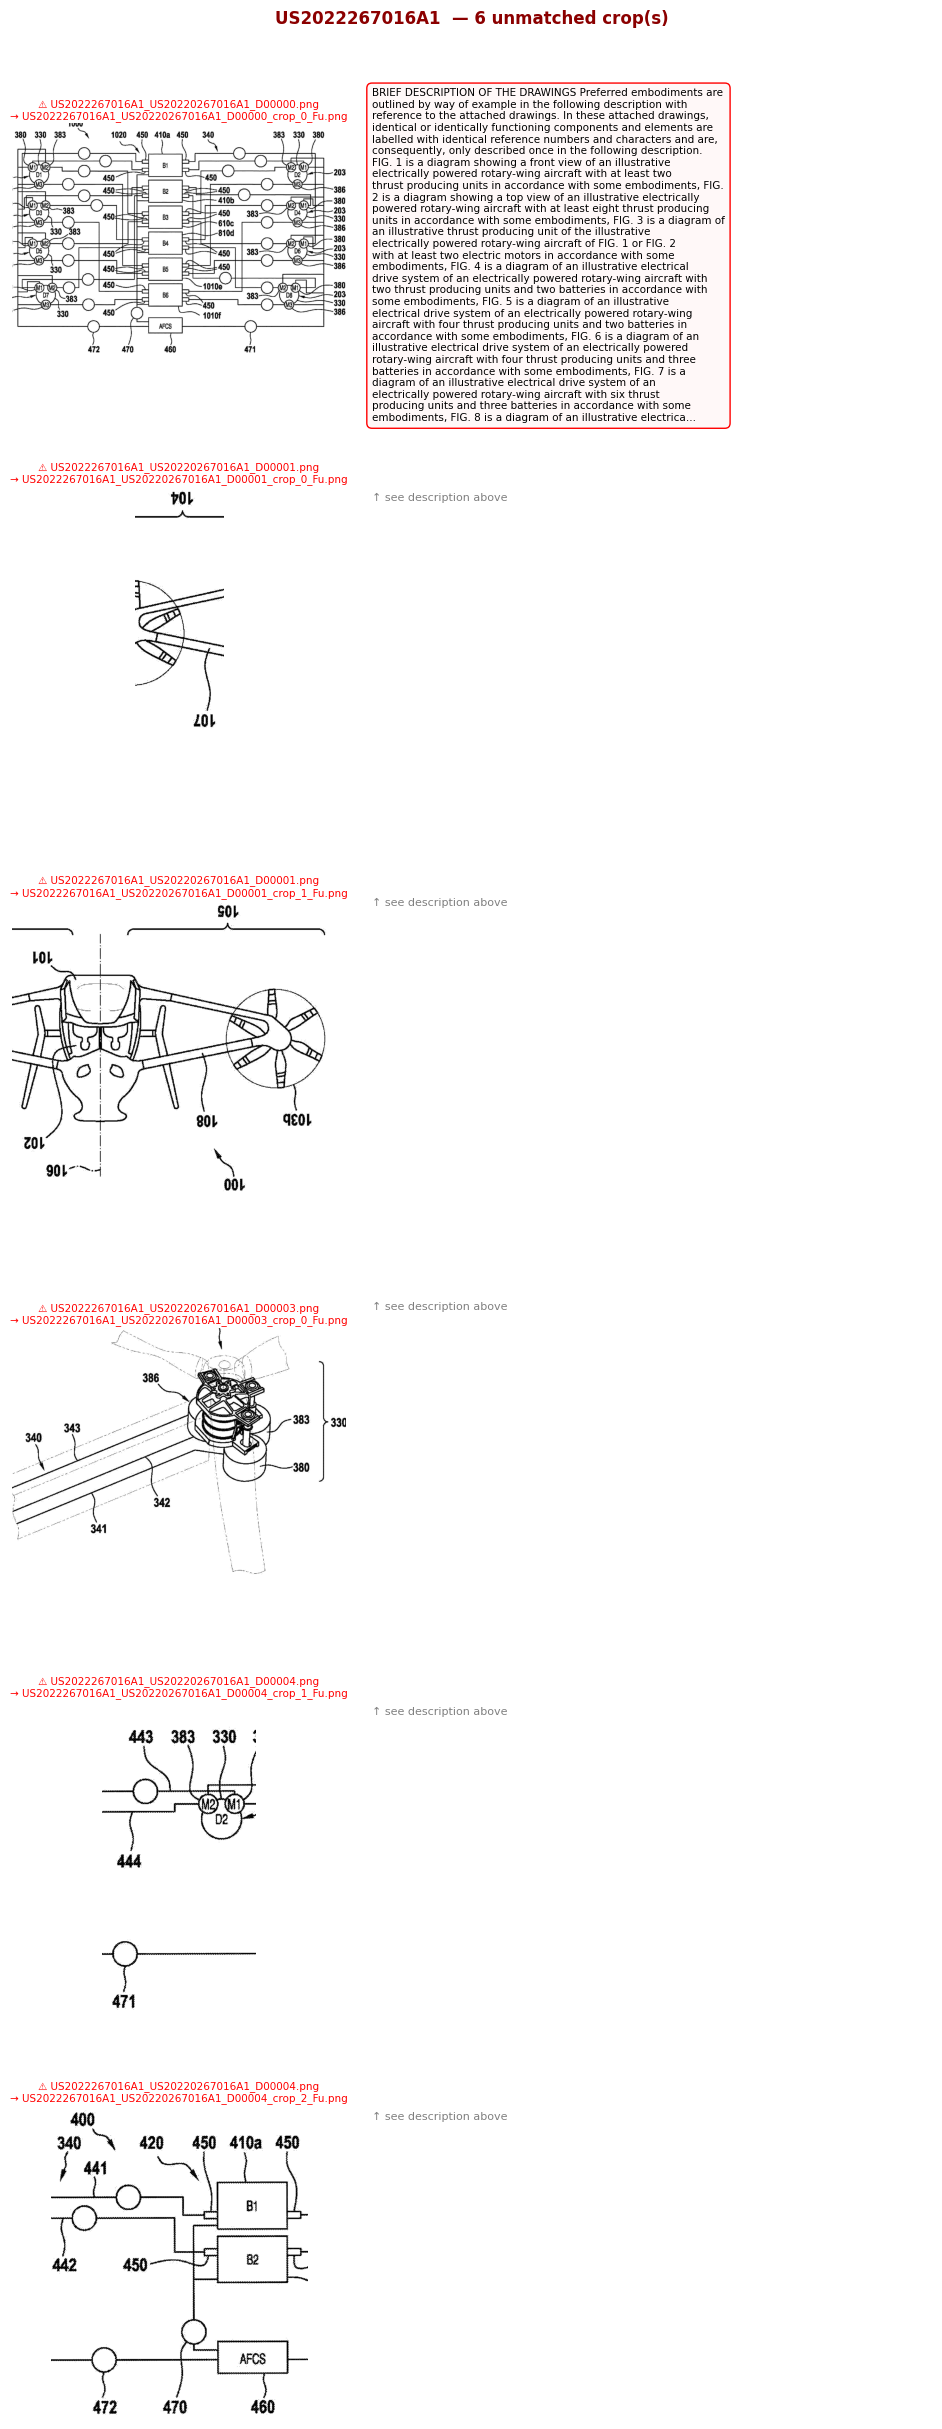

In [10]:
# ── Cell 8 — Flagged (_Fu) reviewer with full description ────────────────────
# For each _Fu crop: shows the image on the left, and the ENTIRE
# Brief Description of the Drawings on the right so you can decide
# which FIG. it corresponds to.

import re, textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path

matched_dir = Path(cfg["paths"]["matched"])
crops_df    = pd.read_csv(Path(cfg["paths"]["data"]) / "crops_mapping.csv")
desc_df     = pd.read_csv(Path(cfg["paths"]["data"]) / "descriptions.csv")
desc_lookup = desc_df.set_index("patent_id")["description_of_drawings"].to_dict()

def clean_desc(text, max_chars=1800):
    if not isinstance(text, str):
        return "(no Brief Description available)"
    t = re.sub(r"\[[\d]+\]", "", text)          # strip paragraph numbers
    t = re.sub(r"\s{2,}", " ", t).strip()
    return t[:max_chars] + ("…" if len(t) > max_chars else "")

flagged = crops_df[crops_df["needs_review"] == True].copy()

if flagged.empty:
    print("No flagged crops — everything was auto-labelled!")
else:
    print(f"{len(flagged)} flagged crops across {flagged['patent_id'].nunique()} patents\n")

    THUMB_W    = 3.5
    DESC_W     = 6.0
    ROW_H      = 4.0
    WRAP_CHARS = 65

    for patent_id, grp in flagged.groupby("patent_id"):
        folders = [p for p in matched_dir.iterdir()
                   if p.name.startswith(patent_id)]
        if not folders:
            print(f"⚠  output folder not found for {patent_id}")
            continue
        out_dir  = folders[0]
        full_txt = clean_desc(desc_lookup.get(patent_id, ""))
        wrapped  = "\n".join(textwrap.wrap(full_txt, WRAP_CHARS))

        n = len(grp)
        fig, axes = plt.subplots(
            n, 2,
            figsize=(THUMB_W + DESC_W, n * ROW_H),
            gridspec_kw={"width_ratios": [THUMB_W, DESC_W]},
        )
        if n == 1:
            axes = [axes]

        fig.suptitle(f"{patent_id}  — {n} unmatched crop(s)",
                     fontsize=12, fontweight="bold", color="darkred", y=1.01)

        for i, (ax_row, (_, r)) in enumerate(zip(axes, grp.iterrows())):
            ax_img, ax_txt = ax_row

            img_path = out_dir / r["output"]
            if img_path.exists():
                ax_img.imshow(mpimg.imread(str(img_path)))
            else:
                ax_img.text(0.5, 0.5, "file missing", ha="center", va="center",
                            color="red", transform=ax_img.transAxes)
            ax_img.axis("off")
            ax_img.set_title(f"⚠ {r['original']}\n→ {r['output']}",
                             fontsize=7.5, color="red", pad=3)

            ax_txt.axis("off")
            # Only print the full description next to the first row to avoid repetition
            if i == 0:
                ax_txt.text(0.02, 0.98, wrapped,
                            va="top", ha="left", fontsize=7.5,
                            transform=ax_txt.transAxes,
                            bbox=dict(boxstyle="round,pad=0.5", fc="#fff8f8", ec="red", lw=1))
            else:
                ax_txt.text(0.02, 0.98, "↑ see description above",
                            va="top", ha="left", fontsize=8, color="grey",
                            transform=ax_txt.transAxes)

        plt.tight_layout()
        plt.show()

## Cell 9 — Duplicate-label audit

Flags two suspicious patterns in `crops_mapping.csv` that signal labelling problems:

1. **Same label on multiple crops of the same sheet** — usually means the sheet has
   side-by-side sub-figures that the vertical splitter kept in one crop, and the OCR
   cascade read the same caption for each row (e.g. three crops all labelled `2A`).
2. **Low label diversity per patent** — many crops but few distinct labels suggests
   the cascade is picking up a neighbouring figure's caption.

These are review hints only — nothing is modified.

In [11]:
# ── Cell 9 — Duplicate-label audit ────────────────────────────────────────────
import pandas as pd
from pathlib import Path

crops_df = pd.read_csv(Path(cfg["paths"]["data"]) / "crops_mapping.csv")
labelled = crops_df[crops_df["needs_review"] == False].copy()

if labelled.empty:
    print("No labelled crops yet — run the pipeline (Cell 4) first.")
else:
    # 1) Same label repeated on the same sheet
    dup_sheet = (
        labelled.groupby(["patent_id", "original", "label"])
        .size().rename("count").reset_index()
        .query("count > 1")
        .sort_values("count", ascending=False)
    )
    print(f"Same label on multiple crops of one sheet: {len(dup_sheet)} cases")
    if not dup_sheet.empty:
        display(dup_sheet.head(20))

    # 2) Label diversity per patent (crops vs distinct labels)
    diversity = (
        labelled.groupby("patent_id")
        .agg(crops=("output", "count"), distinct_labels=("label", "nunique"))
        .assign(ratio=lambda d: (d["distinct_labels"] / d["crops"]).round(2))
        .sort_values("ratio")
    )
    low = diversity[diversity["ratio"] < 0.7]
    print(f"\nPatents with low label diversity (<70% unique): {len(low)}")
    if not low.empty:
        display(low)

Same label on multiple crops of one sheet: 0 cases

Patents with low label diversity (<70% unique): 0
